In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
df = pd.read_csv("listings.csv")

In [9]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61963 entries, 0 to 96870
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              61963 non-null  float64
 1   room_type          61963 non-null  object 
 2   neighbourhood      61963 non-null  object 
 3   latitude           61963 non-null  float64
 4   longitude          61963 non-null  float64
 5   availability_365   61963 non-null  int64  
 6   number_of_reviews  61963 non-null  int64  
 7   minimum_nights     61963 non-null  int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 4.3+ MB


In [10]:
df = df[['price', 'room_type', 'neighbourhood',
         'latitude', 'longitude',
         'availability_365',
         'number_of_reviews',
         'minimum_nights']]

# Data Cleaning

In [11]:
df.isnull().sum()

price                0
room_type            0
neighbourhood        0
latitude             0
longitude            0
availability_365     0
number_of_reviews    0
minimum_nights       0
dtype: int64

In [12]:
df = df.dropna(subset=['price'])

In [13]:
df = df[df["price"] > 0]

# EDA (Exploratory Data Analysis)

In [15]:
df_eda = pd.read_csv("listings.csv")

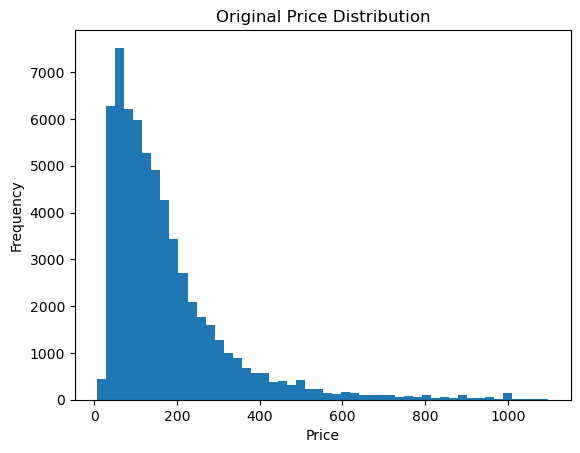

In [16]:
# Price Distribution
df_eda = df_eda[df_eda['price'] < df_eda['price'].quantile(0.99)]

plt.hist(df_eda["price"],bins=50)
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("images/Price Distribution.png")
plt.show()

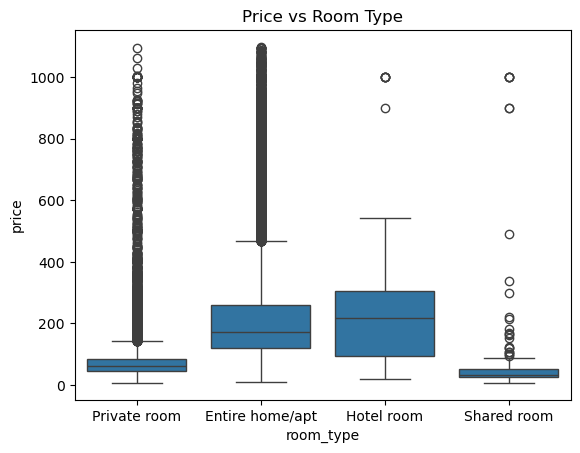

In [17]:
# Price vs Room type
sns.boxplot(x="room_type", y="price", data=df_eda)
plt.title("Price vs Room Type")
plt.savefig("images/Price vs Room Type.png")
plt.show()

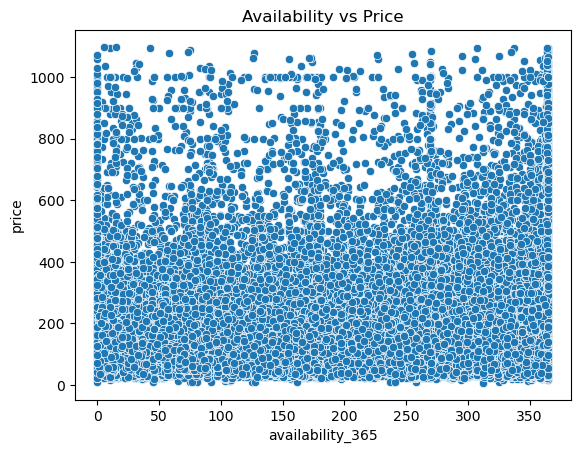

In [18]:
# Availability vs Price

sns.scatterplot(x="availability_365", y="price", data=df_eda)
plt.title("Availability vs Price")
plt.savefig("images/Availability vs Price.png")
plt.show()

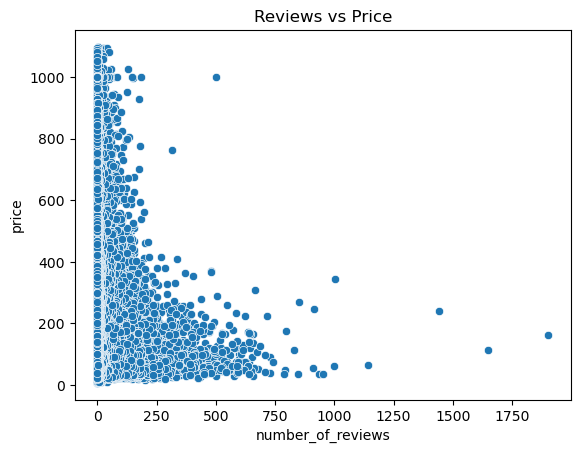

In [19]:
# Reviews vs Price

sns.scatterplot(x="number_of_reviews", y="price", data=df_eda)
plt.title("Reviews vs Price")
plt.savefig("images/Reviews vs Price.png")
plt.show()

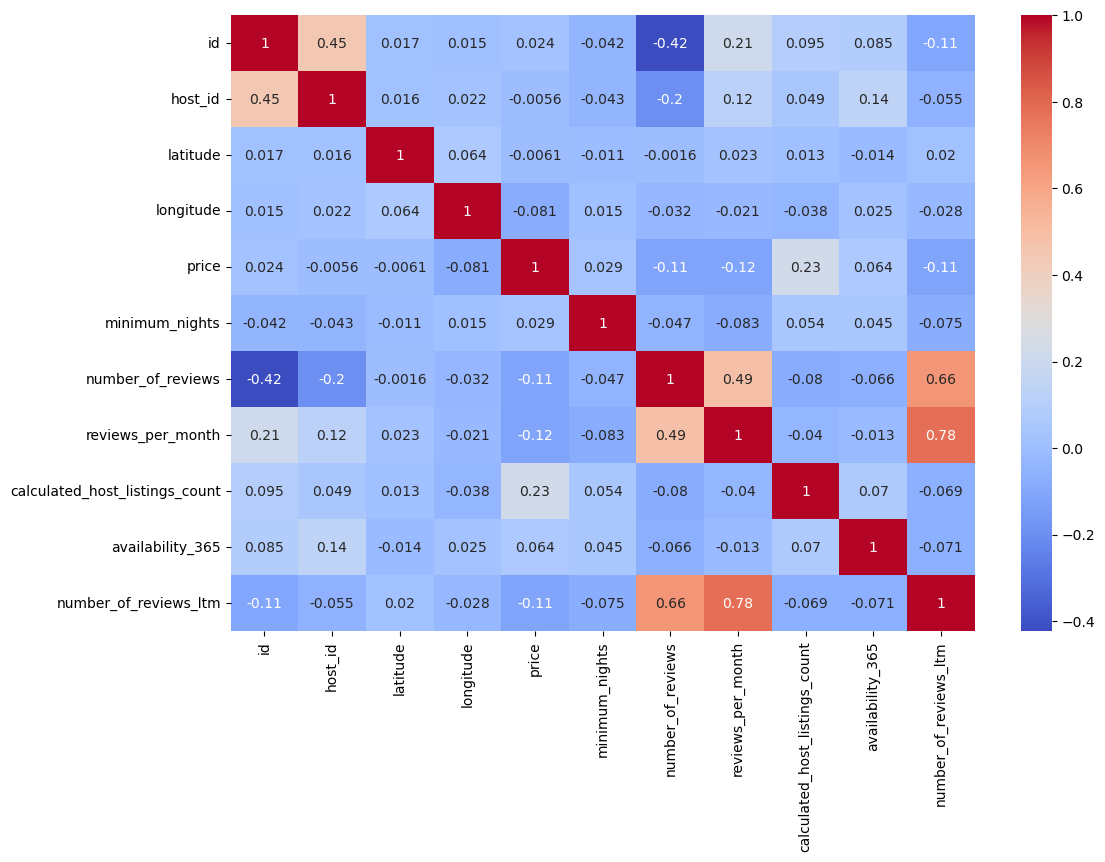

In [20]:
# Correlation Heatmap
df_eda = df_eda.drop(['neighbourhood_group', 'license'], axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(df_eda.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.savefig("images/Correlation Heatmap.png")
plt.show()

# Feature Engineering

In [21]:
df.head()

,price,room_type,neighbourhood,latitude,longitude,availability_365,number_of_reviews,minimum_nights
0,70.0,Private room,Islington,51.56861,-0.11270,331,55,1
1,149.0,Entire home/apt,Kensington and Chelsea,51.48780,-0.16813,199,97,4
2,411.0,Entire home/apt,Westminster,51.52195,-0.14094,80,56,3
4,210.0,Entire home/apt,Tower Hamlets,51.52322,-0.06979,323,15,5
5,280.0,Entire home/apt,Richmond upon Thames,51.48145,-0.28107,324,116,3


In [22]:
# Convert categorical to numerical

df = pd.get_dummies(df, columns=["room_type"], drop_first=True)

In [23]:
top_neigh = df['neighbourhood'].value_counts().head(10).index
df["neighbourhood"] = df["neighbourhood"].apply(lambda x : x if x in top_neigh else "other")

df = pd.get_dummies(df, columns=["neighbourhood"], drop_first=True)

In [24]:
df.head()

,price,latitude,longitude,availability_365,number_of_reviews,minimum_nights,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_Hackney,neighbourhood_Hammersmith and Fulham,neighbourhood_Islington,neighbourhood_Kensington and Chelsea,neighbourhood_Lambeth,neighbourhood_Southwark,neighbourhood_Tower Hamlets,neighbourhood_Wandsworth,neighbourhood_Westminster,neighbourhood_other
0,70.0,51.56861,-0.11270,331,55,1,False,True,False,False,False,True,False,False,False,False,False,False,False
1,149.0,51.48780,-0.16813,199,97,4,False,False,False,False,False,False,True,False,False,False,False,False,False
2,411.0,51.52195,-0.14094,80,56,3,False,False,False,False,False,False,False,False,False,False,False,True,False
4,210.0,51.52322,-0.06979,323,15,5,False,False,False,False,False,False,False,False,False,True,False,False,False
5,280.0,51.48145,-0.28107,324,116,3,False,False,False,False,False,False,False,False,False,False,False,False,True


In [25]:
df["availability_365"] = df["availability_365"] / 365

In [26]:
df["demand_score"] = df["number_of_reviews"] / (df["availability_365"] + 1)

In [27]:
df["min_night_category"] = df["minimum_nights"].apply(lambda x : 1 if x <=3 else 0)

In [28]:
df = df.drop(["availability_365", "number_of_reviews", "minimum_nights"], axis=1)

# Model Training



In [29]:
X = df.drop(["price"], axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
print(X.columns)

Index(['latitude', 'longitude', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'neighbourhood_Hackney', 'neighbourhood_Hammersmith and Fulham',
       'neighbourhood_Islington', 'neighbourhood_Kensington and Chelsea',
       'neighbourhood_Lambeth', 'neighbourhood_Southwark',
       'neighbourhood_Tower Hamlets', 'neighbourhood_Wandsworth',
       'neighbourhood_Westminster', 'neighbourhood_other', 'demand_score',
       'min_night_category'],
      dtype='object')


In [31]:
# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("RMSE : ", rmse_lr)

RMSE :  812.5895594136334


In [32]:
# Random Forest

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
        
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE : ", rmse_rf)

RMSE :  3679.7962300627523


In [33]:
# Decision Tree

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print("RMSE : ", rmse_dt)

RMSE :  9791.743986368972


In [34]:

# Gradient Boosting

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print("RMSE : ", rmse_gb)

RMSE :  881.0761573834233


# Model Comparison 

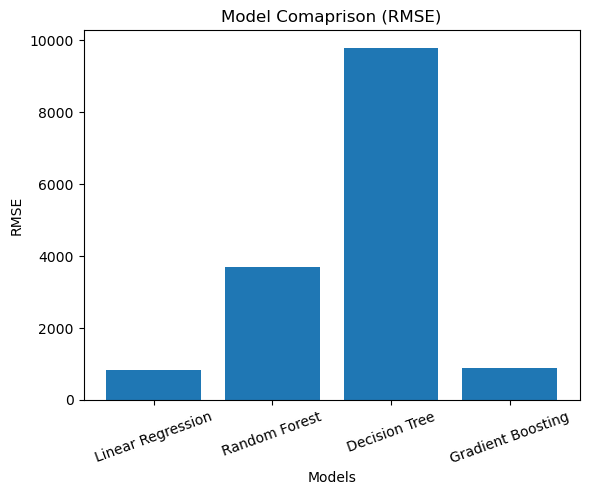

In [35]:
models = ["Linear Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]
rmse_val = [rmse_lr, rmse_rf, rmse_dt, rmse_gb]

plt.bar(models, rmse_val)
plt.title("Model Comaprison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.savefig("images/Model Comaprison.png")
plt.show()

In [36]:
# Select Best Model
# Store actual models
models = {
    "lr": lr,
    "dt": dt,
    "rf": rf,
    "gb": gb
}

# RMSE dictionary
rmse_dict = {
    "lr": rmse_lr,
    "dt": rmse_dt,
    "rf": rmse_rf,
    "gb": rmse_gb
}

# Get best model name
best_model_name = min(rmse_dict, key=rmse_dict.get)

# Get actual model
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: lr


# Feature Importance

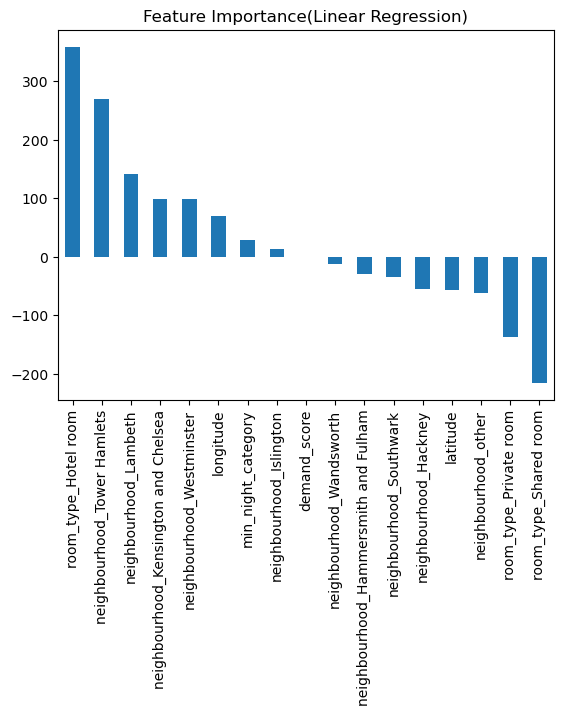

In [37]:
importance = pd.Series(lr.coef_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance(Linear Regression)")
plt.savefig("images/Feature Importance.png")
plt.show()

# Save Model

In [38]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

## 🚀 Deployment using Streamlit

After training and saving the model, we deploy it using Streamlit to create an interactive web application.

### 🔹 Steps:
- Saved the trained model using `joblib`
- Saved feature columns for consistent input format
- Built a Streamlit app (`app.py`) for user interaction

### 🔹 Features of the App:
- User can input property details like latitude, longitude, availability, and demand score
- Model predicts the estimated Airbnb price in real-time

### 🔹 Run the App:
```bash
streamlit run app.py

### 🔹 Outcome:
The deployed Streamlit application allows users to interact with the model and get real-time price predictions. This demonstrates the practical implementation of a machine learning model in a real-world scenario and showcases end-to-end project capability from data preprocessing to deployment.
The deployed Streamlit application allows users to interact with the model and get real-time price predictions. This demonstrates the practical implementation of a machine learning model in a real-world scenario and showcases end-to-end project capability from data preprocessing to deployment.